1. DATA ACQUISITION & NORMALIZATION
✓ Data loaded. Total clean records: 300626

2. RFM AGGREGATION & FEATURE ENGINEERING
✓ RFM aggregation complete. Unique customers: 86732

3. HYPERPARAMETER TUNING (OPTIMIZING SILHOUETTE SCORE)
Running 1 trials... (Trial logs are suppressed)


  0%|          | 0/1 [00:00<?, ?it/s]


✓ Best Silhouette Score: 0.2770
✓ Optimal Number of Clusters (K): 6

4. SEGMENT INTERPRETATION & MODEL FINALIZATION

Generating visual performance reports...


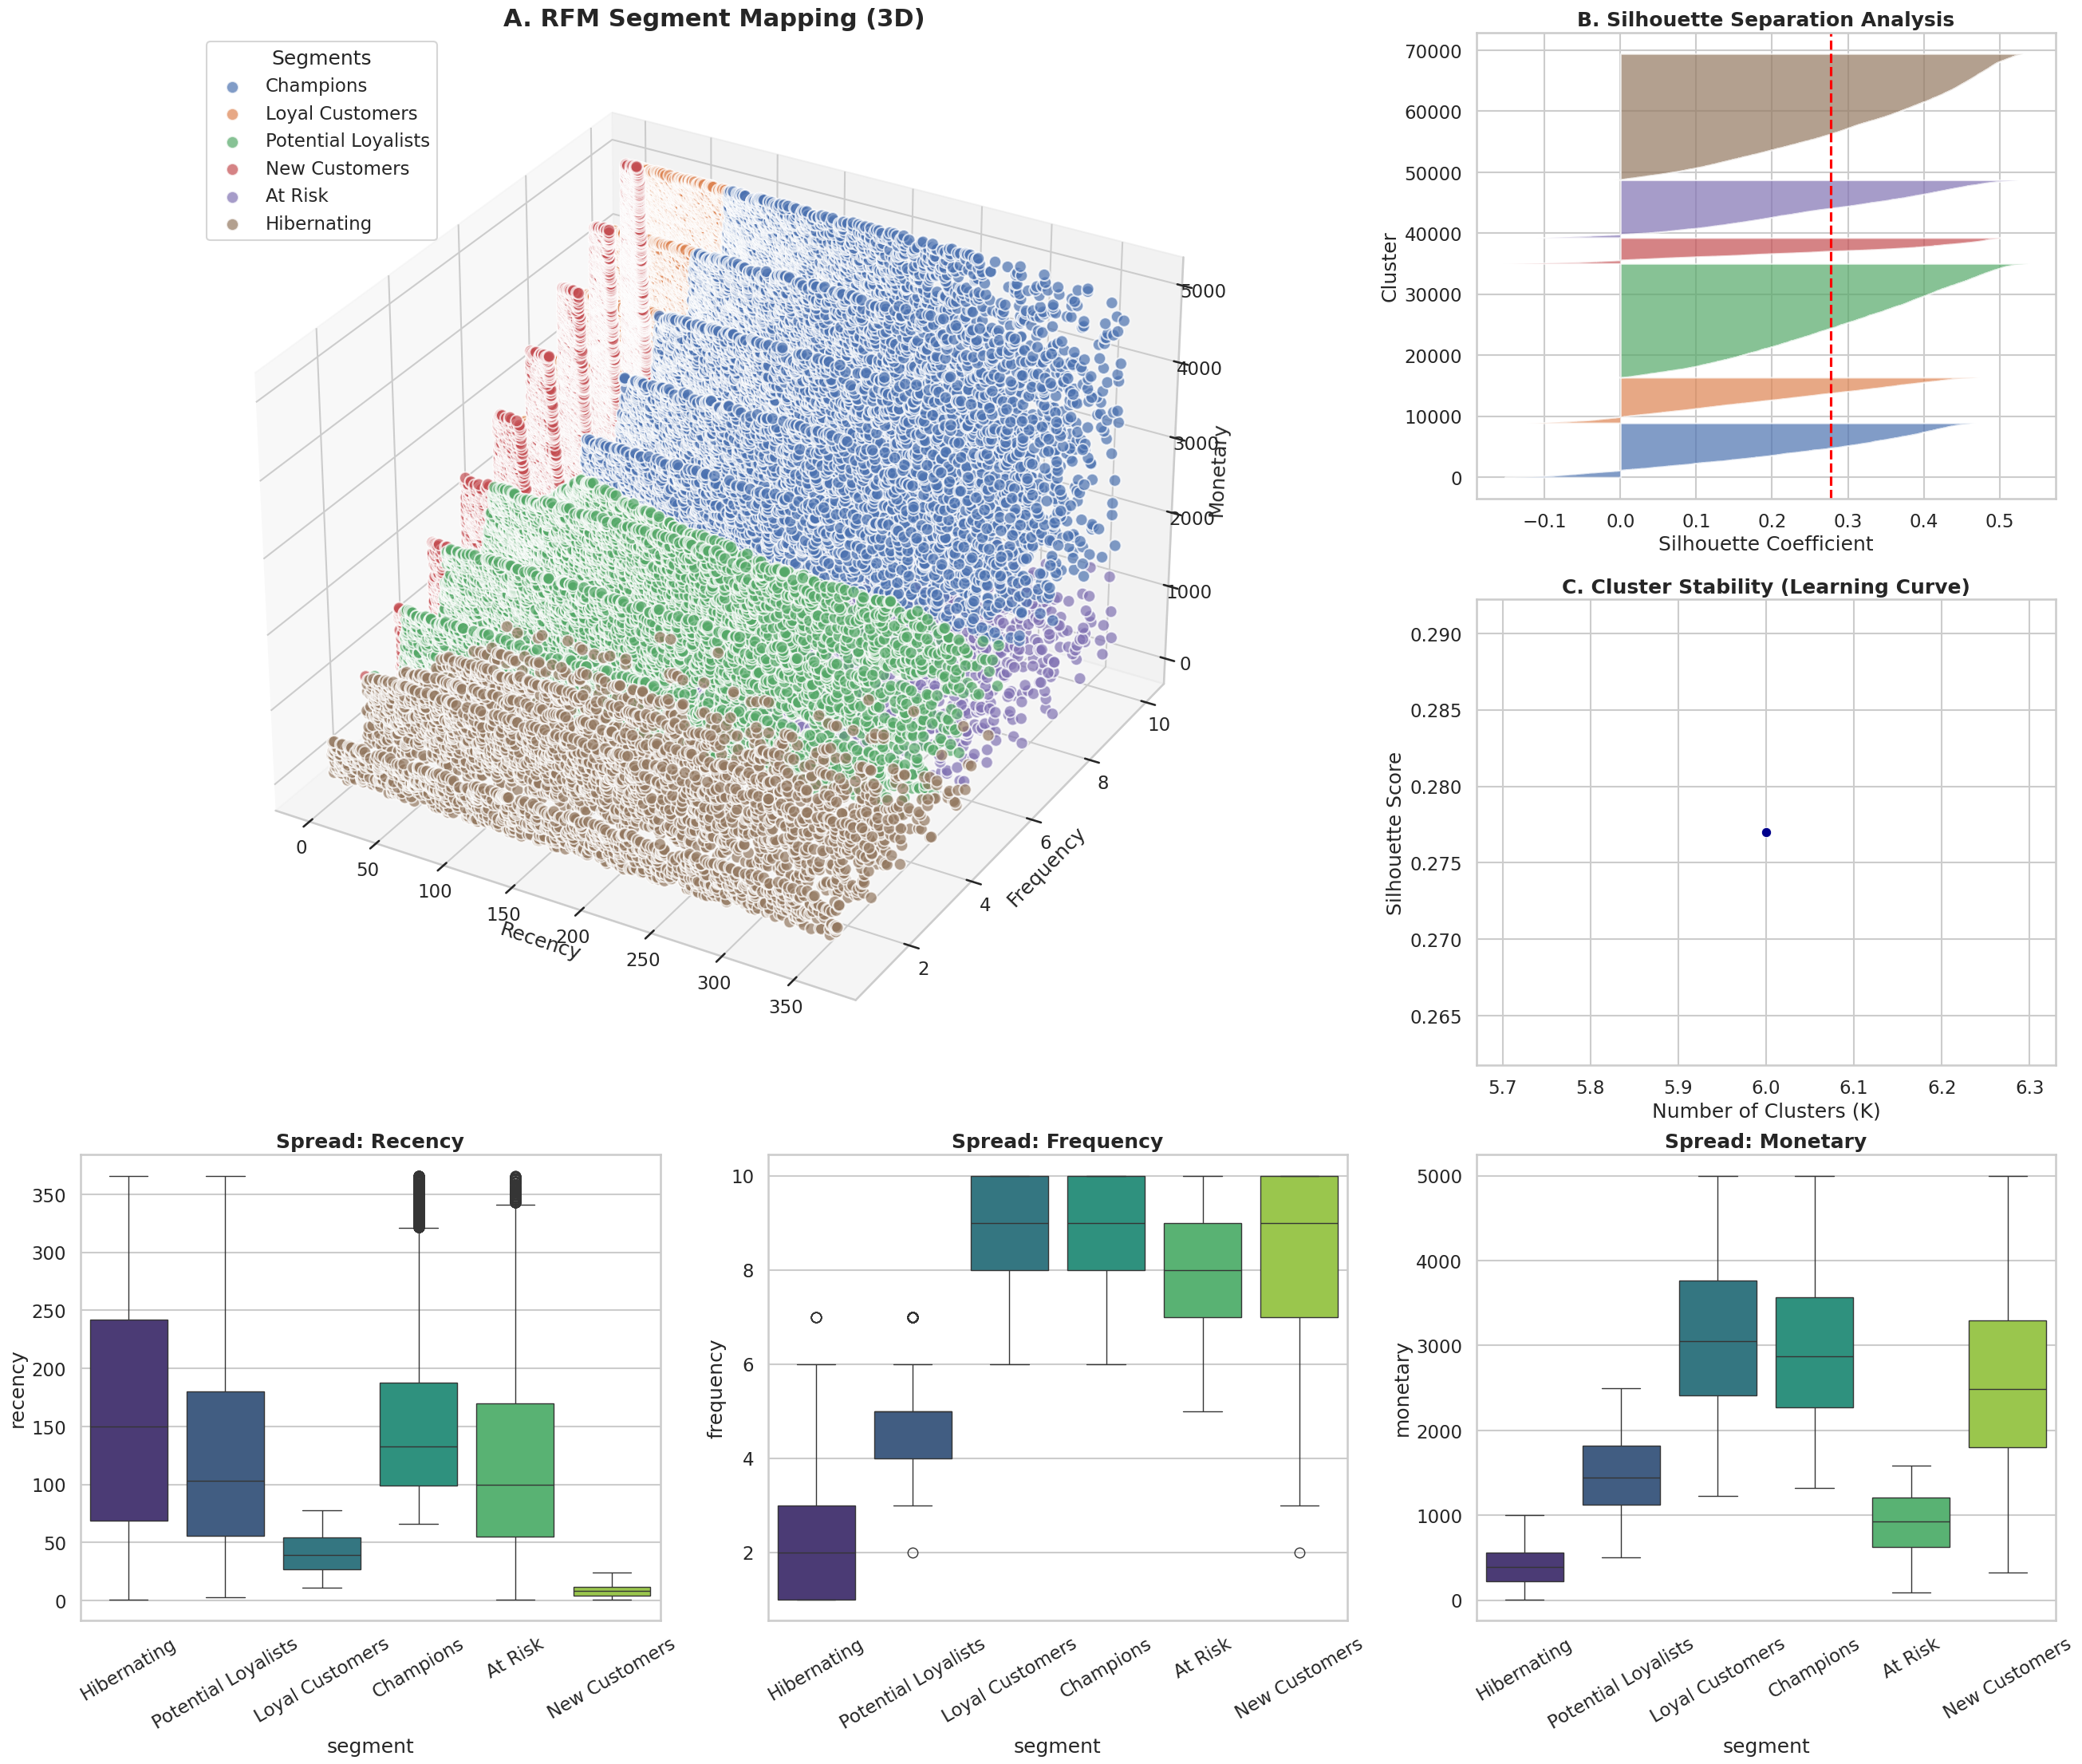


📊 FINAL INTERPRETATION & ACTIONABLE STRATEGY REPORT
[CHAMPIONS]
Total Customers      : 20697 (29.8% of total)
Recency (Avg)        : 151.1 days
Frequency (Avg)      : 8.7 times
Monetary (Avg)       : $2948.5
Strategy Insight     : Reward them! Offer exclusive early access, invite for reviews, and VIP loyalty perks.
--------------------------------------------------------------------------------
[LOYAL CUSTOMERS]
Total Customers      : 18646 (26.9% of total)
Recency (Avg)        : 40.6 days
Frequency (Avg)      : 9.0 times
Monetary (Avg)       : $3091.3
Strategy Insight     : Upsell high-margin products. Engage them in community/referral programs.
--------------------------------------------------------------------------------
[POTENTIAL LOYALISTS]
Total Customers      : 9453 (13.6% of total)
Recency (Avg)        : 125.4 days
Frequency (Avg)      : 4.7 times
Monetary (Avg)       : $1475.8
Strategy Insight     : Offer membership programs and personalized recommendations to increase freq

In [ ]:
# ==================================================================================
# COMPLETE PIPELINE: RFM CUSTOMER SEGMENTATION (FINAL STABLE VERSION 2026)
# FEATURES: OPTUNA TUNING + ROBUST SCALING + SILHOUETTE ANALYSIS + 3D GRID
# ==================================================================================
import os, random, time, warnings
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# --- Environment & Configuration ---
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set(style="whitegrid", context="talk")

CONTROL_SEED = 56
N_TRIALS = 1
DATASET_NAME = 'customer segmentation'
MODEL_NAME = 'kmeans'

def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
set_seed(CONTROL_SEED)

# ----------------------------------------------------------------
# 1. LOADING & DATA PREPARATION
# ----------------------------------------------------------------
DATASET_PATH = '/content/drive/MyDrive/Dataset Personal Project/Business Analysis/Customer_Segmentation.csv'

print("="*70)
print("1. DATA ACQUISITION & NORMALIZATION")
print("="*70)

df = pd.read_csv(DATASET_PATH)
df.columns = df.columns.str.lower().str.strip()

df['full_date'] = pd.to_datetime(df['date'], errors='coerce')

if 'total_purchase_amount' not in df.columns:
    df['total_purchase_amount'] = df['amount'] * df['total_purchases']

df_cleaned = df.dropna(subset=['full_date', 'customer_id', 'total_purchase_amount'])
print(f"✓ Data loaded. Total clean records: {len(df_cleaned)}")

# ----------------------------------------------------------------
# 2. RFM FEATURE ENGINEERING
# ----------------------------------------------------------------
print("\n" + "="*70)
print("2. RFM AGGREGATION & FEATURE ENGINEERING")
print("="*70)

ref_date = df_cleaned['full_date'].max() + pd.Timedelta(days=1)

rfm_df = df_cleaned.groupby('customer_id').agg({
    'full_date': lambda x: (ref_date - x.max()).days,
    'total_purchases': 'max',
    'total_purchase_amount': 'max'
}).reset_index().rename(columns={
    'full_date': 'recency',
    'total_purchases': 'frequency',
    'total_purchase_amount': 'monetary'
})

X_full_raw, X_test_raw, id_full, id_test = train_test_split(
    rfm_df[['recency', 'frequency', 'monetary']], rfm_df['customer_id'],
    test_size=0.20, random_state=CONTROL_SEED
)

print(f"✓ RFM aggregation complete. Unique customers: {len(rfm_df)}")

# ----------------------------------------------------------------
# 3. PREPROCESSING PIPELINE
# ----------------------------------------------------------------
def preprocess_data(train, test):
    """
    Applies Log transformation to handle skewness followed by Robust Scaling.
    """
    scaler = RobustScaler()
    train_sc = scaler.fit_transform(np.log1p(train.fillna(0)))
    test_sc = scaler.transform(np.log1p(test.fillna(0)))
    return train_sc, test_sc, scaler

X_full_scaled, X_test_scaled, final_scaler = preprocess_data(X_full_raw, X_test_raw)

# ----------------------------------------------------------------
# 4. HYPERPARAMETER TUNING (OPTUNA)
# ----------------------------------------------------------------
print("\n" + "="*70)
print(f"3. HYPERPARAMETER TUNING (OPTIMIZING SILHOUETTE SCORE)")
print("="*70)

tuning_results = []

def objective_function(trial):
    k = trial.suggest_int('n_clusters', 3, 6)
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=CONTROL_SEED)
    model.fit(X_full_scaled)
    score = silhouette_score(X_full_scaled, model.labels_)
    tuning_results.append({'k': k, 'score': score})
    return score

study = optuna.create_study(direction='maximize')
print(f"Running {N_TRIALS} trials... (Trial logs are suppressed)")
study.optimize(objective_function, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n✓ Best Silhouette Score: {study.best_value:.4f}")
print(f"✓ Optimal Number of Clusters (K): {study.best_params['n_clusters']}")

# ----------------------------------------------------------------
# 5. FINAL CLUSTERING & SEGMENT NAMING
# ----------------------------------------------------------------
print("\n" + "="*70)
print("4. SEGMENT INTERPRETATION & MODEL FINALIZATION")
print("="*70)

final_k = study.best_params['n_clusters']
final_kmeans = KMeans(n_clusters=final_k, init='k-means++', n_init=20, random_state=CONTROL_SEED)
X_full_raw['cluster'] = final_kmeans.fit_predict(X_full_scaled)

profiles = X_full_raw.groupby('cluster').agg({
    'recency':'mean','frequency':'mean','monetary':'mean','cluster':'count'
}).rename(columns={'cluster':'count'})

# Ranking segments based on business value
profiles['rank'] = (profiles['monetary'].rank() + profiles['frequency'].rank() - profiles['recency'].rank(ascending=False))
profiles = profiles.sort_values('rank', ascending=False)

segment_names = ["Champions", "Loyal Customers", "Potential Loyalists", "New Customers", "At Risk", "Hibernating"]
name_mapping = {cluster: segment_names[i] for i, cluster in enumerate(profiles.index)}
X_full_raw['segment'] = X_full_raw['cluster'].map(name_mapping)

# ----------------------------------------------------------------
# 6. VISUALIZATION (COMPREHENSIVE DASHBOARD)
# ----------------------------------------------------------------
print("\nGenerating visual performance reports...")

#
#

fig = plt.figure(figsize=(26, 22), constrained_layout=True)
gs = fig.add_gridspec(3, 3)

# A. 3D RFM MAPPING
ax1 = fig.add_subplot(gs[0:2, 0:2], projection='3d')
for i, cluster_id in enumerate(profiles.index):
    subset = X_full_raw[X_full_raw['cluster'] == cluster_id]
    ax1.scatter(subset['recency'], subset['frequency'], subset['monetary'],
                s=120, label=name_mapping[cluster_id], alpha=0.7, edgecolors='w')
ax1.set_title("A. RFM Segment Mapping (3D)", fontsize=22, fontweight='bold')
ax1.set_xlabel('Recency'); ax1.set_ylabel('Frequency'); ax1.set_zlabel('Monetary')
ax1.legend(loc='upper left', title="Segments")

# B. SILHOUETTE ANALYSIS (Clustering "Actual vs Predicted")
ax2 = fig.add_subplot(gs[0, 2])
sample_silhouette_values = silhouette_samples(X_full_scaled, X_full_raw['cluster'])
y_lower = 10
for i in range(final_k):
    ith_cluster_sil_vals = sample_silhouette_values[X_full_raw['cluster'] == i]
    ith_cluster_sil_vals.sort()
    size_cluster_i = ith_cluster_sil_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_vals, alpha=0.7)
    y_lower = y_upper + 10
ax2.axvline(x=study.best_value, color="red", linestyle="--")
ax2.set_title("B. Silhouette Separation Analysis", fontsize=18, fontweight='bold')
ax2.set_xlabel("Silhouette Coefficient"); ax2.set_ylabel("Cluster")

# C. CLUSTER OPTIMIZATION CURVE (Clustering "Learning Curve")
ax3 = fig.add_subplot(gs[1, 2])
opt_df = pd.DataFrame(tuning_results).groupby('k').max().reset_index()
sns.lineplot(x='k', y='score', data=opt_df, marker='o', ax=ax3, color='darkblue', lw=3)
ax3.set_title("C. Cluster Stability (Learning Curve)", fontsize=18, fontweight='bold')
ax3.set_xlabel("Number of Clusters (K)"); ax3.set_ylabel("Silhouette Score")

# D-F. METRIC SPREAD (BOXPLOTS)
metrics = ['recency', 'frequency', 'monetary']
for i, metric in enumerate(metrics):
    ax = fig.add_subplot(gs[2, i])
    sns.boxplot(x='segment', y=metric, data=X_full_raw, palette="viridis", ax=ax)
    ax.set_title(f"Spread: {metric.capitalize()}", fontsize=18, fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=30)

plt.show()

# ----------------------------------------------------------------
# 7. STRATEGY REPORT & DATA EXPORT
# ----------------------------------------------------------------
print("\n" + "="*80)
print(f"📊 FINAL INTERPRETATION & ACTIONABLE STRATEGY REPORT")
print("="*80)

business_strategies = {
    "Champions": "Reward them! Offer exclusive early access, invite for reviews, and VIP loyalty perks.",
    "Loyal Customers": "Upsell high-margin products. Engage them in community/referral programs.",
    "Potential Loyalists": "Offer membership programs and personalized recommendations to increase frequency.",
    "New Customers": "Provide onboarding support. Offer special discounts for the second purchase to ensure return.",
    "At Risk": "Send reactivation emails or win-back offers. Survey them to identify pain points.",
    "Hibernating": "Low priority. Use automated mass-market campaigns with high-discount offers."
}

for cluster_id in profiles.index:
    row = profiles.loc[cluster_id]
    segment_name = name_mapping[cluster_id]
    pop_percentage = (row['count'] / len(X_full_raw)) * 100

    print(f"[{segment_name.upper()}]")
    print(f"{'Total Customers':<20} : {int(row['count'])} ({pop_percentage:.1f}% of total)")
    print(f"{'Recency (Avg)':<20} : {row['recency']:.1f} days")
    print(f"{'Frequency (Avg)':<20} : {row['frequency']:.1f} times")
    print(f"{'Monetary (Avg)':<20} : ${row['monetary']:.1f}")
    print(f"{'Strategy Insight':<20} : {business_strategies.get(segment_name)}")
    print("-" * 80)

# Exporting results
output_filename = f"{DATASET_NAME}_{MODEL_NAME}.csv"
test_preds = final_kmeans.predict(X_test_scaled)
submission = pd.DataFrame({
    'customer_id': id_test.values,
    'segment': [name_mapping.get(p, "Unassigned") for p in test_preds]
})
submission.to_csv(output_filename, index=False)

print(f"\n✅ PROCESS COMPLETE. Results saved to '{output_filename}'")
print("="*80)